# Indonesian Lip Reading (IndoLR) — BiGRU Pipeline

Notebook ini dibuat berdasarkan kebutuhan untuk dijalankan di dalam env google colab dan untuk menjalankannya secara offline butuh beberapa penyesuaian seperti pada

1. Bagian backup (hanya dibutuhkan saat memakai colab karena harus mengganti runtime).
2. Perbaikan Config untuk penyesuain path.

**Alur kerja :**

1. **Bagian 1 (Setup & Download Data)** — jalankan di runtime apa saja (CPU cukup).
2. **Bagian 2 (Preprocessing / Lip Landmark Extraction)**.
3. **Ganti runtime ke GPU (T4)** .
4. **Bagian 3 (Load Data + Model + Training)**.
5. **Bagian 4 (Evaluasi)** — precision/recall/F1/confusion matrix pada test set.
6. **Bagian 5 (Inference Demo)** — coba prediksi 1 video baru + text-to-speech.

Semua konfigurasi penting (path, ukuran gambar, panjang sequence, dsb) dikumpulkan di satu sel `CONFIG` di Bagian 1 supaya mudah diubah tanpa harus mengubah banyak sel.

## Bagian 1 — Setup, Konfigurasi, dan Download Dataset

*(Runtime: CPU cukup)*

In [ ]:
# @title 1.1 CONFIG — ubah path/parameter di sini saja
import os

CONFIG = {
    # --- Path ---
    "ROOT_VIDEO": "/content/data",                       # video mentah hasil download kaggle
    "OUT_ROOT": "/content/precomputed",                  # hasil preprocessing (lokal, sementara)
    "DRIVE_BACKUP_DIR": "/content/drive/MyDrive/IndoLR/precomputed",  # backup permanen di Drive
    "MODEL_TASK_PATH": "/content/face_landmarker.task",

    # --- Preprocessing ---
    "SEQ_LEN_WORD": 30,       # sesuai jurnal: 30 frame untuk dataset kata
    "SEQ_LEN_PHRASE": 40,     # sesuai jurnal: 40 frame untuk dataset frasa
    "TARGET_SIZE": (80, 80),  # sesuai jurnal: 80x80
    "MAX_FRAMES_READ": 400,
    "PAD_RATIO": 0.15,
    "MIN_BOX_SIZE": 20,
    "MAX_WORD_INDEX": 11,     # folder kata "1 Maaf" ... "10 Awas" (indeks <= 11 -> word dataset)

    # --- Training ---
    "BATCH_SIZE": 16,
    "LEARNING_RATE": 1e-3,
    "EPOCHS": 80,
    "PATIENCE": 8,            # early stopping
    "SEED": 27,
    "USE_WANDB": True,        # aktif by default -- integrasi wandb untuk tracking per-kelas
    "PREPROCESS_VERSION": "bbox_v2_mouth_center_no_extra_pad",  # PENTING: catat versi formula bbox
                              # supaya kalau nanti dipakai ulang di script lain (mobile/live-inference),
                              # formula bisa dicocokkan lewat metadata checkpoint, bukan ditebak/disalin manual.
}

os.makedirs(CONFIG["OUT_ROOT"], exist_ok=True)
os.makedirs(CONFIG["DRIVE_BACKUP_DIR"], exist_ok=True)
print("Konfigurasi siap.")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Konfigurasi siap.
  ROOT_VIDEO: /content/data
  OUT_ROOT: /content/precomputed
  DRIVE_BACKUP_DIR: /content/drive/MyDrive/IndoLR/precomputed
  MODEL_TASK_PATH: /content/face_landmarker.task
  SEQ_LEN_WORD: 30
  SEQ_LEN_PHRASE: 40
  TARGET_SIZE: (80, 80)
  MAX_FRAMES_READ: 400
  PAD_RATIO: 0.15
  MIN_BOX_SIZE: 20
  MAX_WORD_INDEX: 11
  BATCH_SIZE: 16
  LEARNING_RATE: 0.001
  EPOCHS: 80
  PATIENCE: 8
  SEED: 27
  USE_WANDB: True
  PREPROCESS_VERSION: bbox_v2_mouth_center_no_extra_pad


In [ ]:
# @title 1.2 download Kaggle
!pip install -q kagglehub

In [ ]:
# @title 1.3 Download dataset IndoLR dari Kaggle
import kagglehub

kaggle_path = kagglehub.dataset_download("abasset/indolr")
print("Dataset terunduh di:", kaggle_path)

100%|██████████| 4.26G/4.26G [00:50<00:00, 91.1MB/s]

Extracting files...


Dataset terunduh di: /root/.cache/kagglehub/datasets/abasset/indolr/versions/1


In [ ]:
# @title 1.4 Salin data video ke /content/data (working dir)
import shutil, glob

os.makedirs(CONFIG["ROOT_VIDEO"], exist_ok=True)

# Salin seluruh isi dataset (folder per orang -> folder per kata/frasa -> video .mp4)
# Menggunakan dirs_exist_ok=True supaya aman dijalankan ulang tanpa error.
shutil.copytree(kaggle_path, CONFIG["ROOT_VIDEO"], dirs_exist_ok=True)

n_videos = len(glob.glob(os.path.join(CONFIG["ROOT_VIDEO"], "**", "*.mp4"), recursive=True))
print(f"Total video ditemukan: {n_videos}")

Total video ditemukan: 5807


In [ ]:
#memperbaiki adanya folder double dari data.
!mv "/content/data/8 Glamor ( Bella )/8 Glamor ( Bella ) - Copy - Copy/"* "/content/data/8 Glamor ( Bella )/"

In [ ]:
# @title 1.5 Download model MediaPipe Face Landmarker
!wget -O {CONFIG['MODEL_TASK_PATH']} -q https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task
print("Model landmarker tersimpan di:", CONFIG['MODEL_TASK_PATH'])

Model landmarker tersimpan di: /content/face_landmarker.task


In [ ]:
# @title 1.6 Install dependencies
!pip install -q mediapipe opencv-python-headless gTTS scikit-learn imageio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 125.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 11.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wandb 0.28.0 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.
huggingface-hub 1.23.0 requires click<9.0.0,>=8.4.2, but you have click 8.1.8 which is incompatible.


## Bagian 2 — Preprocessing (Lip Landmark Extraction)



In [ ]:
# @title 2.1 Import & inisialisasi MediaPipe FaceLandmarker (landmark-based pipeline)
import os, glob, re
import cv2
import numpy as np
from pathlib import Path
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

base_options = mp_python.BaseOptions(model_asset_path=CONFIG["MODEL_TASK_PATH"])
landmarker_options = mp_vision.FaceLandmarkerOptions(
    base_options=base_options,
    num_faces=1,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
)
detector = mp_vision.FaceLandmarker.create_from_options(landmarker_options)

# --- Titik landmark bibir: FULL 40 koneksi (outer+inner, upper+lower) ---
# Alasan tetap pakai full set (bukan direduksi): di representasi koordinat,
# menambah titik cuma menambah beberapa angka input (murah), sementara inner
# ring membawa informasi fonetik penting (derajat bukaan mulut) yang hilang
# kalau cuma pakai outer ring.
LIPS_PAIRS = [
    (61, 146), (146, 91), (91, 181), (181, 84), (84, 17), (17, 314),
    (314, 405), (405, 321), (321, 375), (375, 291),
    (61, 185), (185, 40), (40, 39), (39, 37), (37, 0),
    (0, 267), (267, 269), (269, 270), (270, 409), (409, 291),
    (78, 95), (95, 88), (88, 178), (178, 87), (87, 14), (14, 317),
    (317, 402), (402, 318), (318, 324), (324, 308),
    (78, 191), (191, 80), (80, 81), (81, 82), (82, 13),
    (13, 312), (312, 311), (311, 310), (310, 415), (415, 308),
]

def _unique_indices_from_pairs(pairs):
    seen = []
    for a, b in pairs:
        if a not in seen: seen.append(a)
        if b not in seen: seen.append(b)
    return seen

LIPS_IDX = sorted(_unique_indices_from_pairs(LIPS_PAIRS))
N_LIP_POINTS = len(LIPS_IDX)  # harus 40

# Titik referensi mata untuk normalisasi (STABIL, tidak berubah saat bicara).
# Index standar MediaPipe Face Mesh: sudut luar mata kiri & kanan.
LEFT_EYE_OUTER_IDX = 33
RIGHT_EYE_OUTER_IDX = 263

print(f"Jumlah titik landmark bibir: {N_LIP_POINTS}")

Jumlah titik landmark bibir: 40


In [ ]:
# @title 2.2 Fungsi ekstraksi landmark + normalisasi + deteksi segmen ucapan + resampling
import numpy as np
from scipy.ndimage import uniform_filter1d, label as ndi_label

TARGET_SEQ_FEATURE_DIM = N_LIP_POINTS * 2 + 1  # (x,y) tiap titik bibir + 1 fitur MAR
MAX_FRAMES_READ = CONFIG["MAX_FRAMES_READ"]


# ============================================================
# BAGIAN 1: Ekstraksi & normalisasi per-frame (TIDAK BERUBAH)
# ============================================================

def extract_raw_points(landmarks, w, h):
    """Ambil koordinat piksel (x,y) untuk titik bibir + 2 titik mata (referensi normalisasi)."""
    lip_pts = np.array([[landmarks[i].x * w, landmarks[i].y * h] for i in LIPS_IDX],
                        dtype=np.float32)
    left_eye = np.array([landmarks[LEFT_EYE_OUTER_IDX].x * w,
                          landmarks[LEFT_EYE_OUTER_IDX].y * h], dtype=np.float32)
    right_eye = np.array([landmarks[RIGHT_EYE_OUTER_IDX].x * w,
                           landmarks[RIGHT_EYE_OUTER_IDX].y * h], dtype=np.float32)
    return lip_pts, left_eye, right_eye


def normalize_frame(lip_pts, left_eye, right_eye):
    """Normalisasi rotasi + skala (jarak antar-mata) + translasi (centroid bibir).
    Lihat penjelasan lengkap di diskusi sebelumnya -- TIDAK BERUBAH."""
    eye_vec = right_eye - left_eye
    eye_dist = np.linalg.norm(eye_vec) + 1e-6
    angle = np.arctan2(eye_vec[1], eye_vec[0])

    cos_a, sin_a = np.cos(-angle), np.sin(-angle)
    rot = np.array([[cos_a, -sin_a], [sin_a, cos_a]], dtype=np.float32)

    lip_centroid = lip_pts.mean(axis=0)
    centered = lip_pts - lip_centroid
    rotated = centered @ rot.T
    normalized = rotated / eye_dist

    return normalized


def compute_mar(normalized_pts):
    """Mouth Aspect Ratio -- TIDAK BERUBAH."""
    idx_map = {v: i for i, v in enumerate(LIPS_IDX)}
    top_inner = normalized_pts[idx_map[13]]
    bottom_inner = normalized_pts[idx_map[14]]
    left_inner = normalized_pts[idx_map[78]]
    right_inner = normalized_pts[idx_map[308]]

    vert = np.linalg.norm(top_inner - bottom_inner)
    horiz = np.linalg.norm(left_inner - right_inner) + 1e-6
    return vert / horiz


# ============================================================
# BAGIAN 2: Deteksi segmen ucapan + resampling (BARU, pengganti
# center_pad_feature_sequence yang lama)
# ============================================================

def smooth_mar(mar_seq, window=3):
    return uniform_filter1d(mar_seq, size=window, mode="nearest")


def find_active_segments(mar_seq, k_std=0.5):
    """Cari SEMUA segmen contiguous di atas threshold -- bisa lebih dari 1
    (misal: decak bibir/tarik napas terdeteksi terpisah dari ucapan sesungguhnya)."""
    smoothed = smooth_mar(mar_seq)
    baseline = np.percentile(smoothed, 20)
    spread = np.std(smoothed) + 1e-6
    threshold = baseline + k_std * spread

    active_mask = smoothed > threshold
    labeled, n_segments = ndi_label(active_mask)

    segments = []
    for seg_id in range(1, n_segments + 1):
        idx = np.flatnonzero(labeled == seg_id)
        start, end = idx[0], idx[-1]
        peak = smoothed[idx].max()
        duration = end - start + 1
        segments.append({"start": start, "end": end, "peak": peak, "duration": duration})

    return segments, threshold


def select_speech_segment(segments, min_peak_ratio=0.7, min_duration=5):
    """Dari beberapa segmen aktif, pilih SATU yang paling mewakili ucapan
    sesungguhnya (bukan decak bibir/buka-sedikit/tarik-napas) -- lihat
    penjelasan heuristik di diskusi sebelumnya."""
    if len(segments) == 0:
        return None
    if len(segments) == 1:
        return segments[0]

    filtered = [s for s in segments if s["duration"] >= min_duration]
    if len(filtered) == 0:
        filtered = segments

    max_peak = max(s["peak"] for s in filtered)
    for s in filtered:
        s["score"] = s["peak"] * (1.0 if s["peak"] >= min_peak_ratio * max_peak else 0.3) * np.sqrt(s["duration"])

    return max(filtered, key=lambda s: s["score"])


def find_speech_interval(mar_seq, k_std=0.5, min_duration=5, margin=2):
    """Pengganti symmetric-trim / active-window sebelumnya. Segmentasi dulu,
    baru pilih 1 segmen ucapan -- segmen lain (noise) DIBUANG."""
    segments, threshold = find_active_segments(mar_seq, k_std=k_std)

    if len(segments) == 0:
        return 0, len(mar_seq) - 1

    best = select_speech_segment(segments, min_duration=min_duration)
    onset = max(0, best["start"] - margin)
    offset = min(len(mar_seq) - 1, best["end"] + margin)

    if (offset - onset + 1) < min_duration:
        center = (onset + offset) // 2
        onset = max(0, center - min_duration // 2)
        offset = min(len(mar_seq) - 1, onset + min_duration - 1)

    return onset, offset


def resample_sequence(frames, seq_len):
    """Resample sequence (panjang berapa pun) jadi TEPAT seq_len frame via
    interpolasi linear -- BUKAN crop/pad seperti center_pad_feature_sequence lama."""
    arr = np.stack(frames)
    n, D = arr.shape

    if n == seq_len:
        return arr.astype(np.float32)
    if n == 1:
        return np.repeat(arr, seq_len, axis=0).astype(np.float32)

    orig_idx = np.linspace(0, 1, n)
    new_idx = np.linspace(0, 1, seq_len)

    resampled = np.zeros((seq_len, D), dtype=np.float32)
    for d in range(D):
        resampled[:, d] = np.interp(new_idx, orig_idx, arr[:, d])
    return resampled


def extract_speech_and_resample(frames, seq_len):
    """Pipeline lengkap: deteksi segmen ucapan -> potong ke segmen itu SAJA
    (buang noise di luar) -> resample jadi seq_len frame."""
    if len(frames) == 0:
        return np.zeros((seq_len, TARGET_SEQ_FEATURE_DIM), dtype=np.float32)

    mar_seq = np.array([f[-1] for f in frames])
    onset, offset = find_speech_interval(mar_seq)
    speech_frames = frames[onset:offset + 1]

    return resample_sequence(speech_frames, seq_len)


# ============================================================
# BAGIAN 3: Loop utama pemrosesan 1 video (SAMA seperti sebelumnya,
# HANYA baris return paling akhir yang berubah)
# ============================================================

def process_video_landmarks(video_path, seq_len):
    cap = cv2.VideoCapture(video_path)
    frames_feat = []
    last_feat = None
    total, success = 0, 0

    while cap.isOpened() and total < MAX_FRAMES_READ:
        ret, frame = cap.read()
        if not ret: break
        total += 1

        feat = last_feat
        try:
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB,
                               data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            result = detector.detect(mp_img)
            if result.face_landmarks:
                landmarks = result.face_landmarks[0]
                h, w = frame.shape[:2]
                lip_pts, left_eye, right_eye = extract_raw_points(landmarks, w, h)
                normalized = normalize_frame(lip_pts, left_eye, right_eye)
                mar = compute_mar(normalized)
                feat = np.concatenate([normalized.flatten(), [mar]]).astype(np.float32)
                last_feat = feat
                success += 1
        except Exception:
            pass

        if feat is not None:
            frames_feat.append(feat)

    cap.release()
    ratio = success / max(total, 1)

    # >>> INI SATU-SATUNYA BARIS YANG BERUBAH <
    # Sebelumnya: center_pad_feature_sequence(frames_feat, seq_len)
    # Sekarang  : extract_speech_and_resample(frames_feat, seq_len)
    return extract_speech_and_resample(frames_feat, seq_len), total, success, ratio

In [ ]:
# @title 2.3 Jalankan preprocessing landmark untuk seluruh dataset
def extract_leading_number(name):
    m = re.match(r'^\(?\s*(\d+)', name.strip())
    return int(m.group(1)) if m else None

def sanitize_name(name):
    return re.sub(r'[^A-Za-z0-9_-]+', '_', name.strip())

def run_preprocessing_landmark():
    os.makedirs(CONFIG["OUT_ROOT"], exist_ok=True)
    log = []

    for person in sorted(os.listdir(CONFIG["ROOT_VIDEO"])):
        p_path = os.path.join(CONFIG["ROOT_VIDEO"], person)
        if not os.path.isdir(p_path): continue
        safe_person = sanitize_name(person)

        for keyword in sorted(os.listdir(p_path)):
            kw_path = os.path.join(p_path, keyword)
            if not os.path.isdir(kw_path): continue
            num = extract_leading_number(keyword)
            if num is None: continue

            seq_len = CONFIG["SEQ_LEN_WORD"] if num <= CONFIG["MAX_WORD_INDEX"] else CONFIG["SEQ_LEN_PHRASE"]
            out_kw = os.path.join(CONFIG["OUT_ROOT"], keyword)
            Path(out_kw).mkdir(parents=True, exist_ok=True)
            print(f"\n▶ {keyword}  [{person}]  (seq_len={seq_len})")

            for f in glob.glob(os.path.join(kw_path, "*.mp4")):
                out_name = f"{safe_person}__{Path(f).stem}.npy"
                out_path = os.path.join(out_kw, out_name)
                if os.path.exists(out_path): continue
                try:
                    arr, total, success, ratio = process_video_landmarks(f, seq_len)
                    np.save(out_path, arr)
                    log.append((f, total, success, ratio))
                    print(f"  ✓ {Path(f).name}: frames={total}, valid_landmark={success}, ratio={ratio:.2f}")
                except Exception as e:
                    print(f"  ❌ Skip {f}: {e}")
    return log

preprocessing_log = run_preprocessing_landmark()
print(f"\nSelesai. {len(preprocessing_log)} video diproses.")

Output streaming akan dipotong hingga 5000 baris terakhir.
▶ 14 Minta Tolong  [2 Pointy Natural ( Sandy )]  (seq_len=40)
  ✓ WIN_20240102_17_41_03_Pro.mp4: frames=68, valid_landmark=68, ratio=1.00
  ✓ WIN_20240102_17_43_53_Pro.mp4: frames=79, valid_landmark=79, ratio=1.00
  ✓ WIN_20240102_17_43_49_Pro.mp4: frames=58, valid_landmark=58, ratio=1.00
  ✓ WIN_20240102_17_40_43_Pro.mp4: frames=60, valid_landmark=60, ratio=1.00
  ✓ WIN_20240102_17_45_22_Pro.mp4: frames=73, valid_landmark=73, ratio=1.00
  ✓ WIN_20240102_17_42_38_Pro.mp4: frames=78, valid_landmark=78, ratio=1.00
  ✓ WIN_20240102_17_44_44_Pro.mp4: frames=73, valid_landmark=73, ratio=1.00
  ✓ WIN_20240102_17_43_59_Pro.mp4: frames=78, valid_landmark=78, ratio=1.00
  ✓ WIN_20240102_17_41_43_Pro.mp4: frames=79, valid_landmark=79, ratio=1.00
  ✓ WIN_20240102_17_45_27_Pro.mp4: frames=79, valid_landmark=79, ratio=1.00
  ✓ WIN_20240102_17_44_40_Pro.mp4: frames=72, valid_landmark=72, ratio=1.00
  ✓ WIN_20240102_17_44_15_Pro.mp4: frames=6

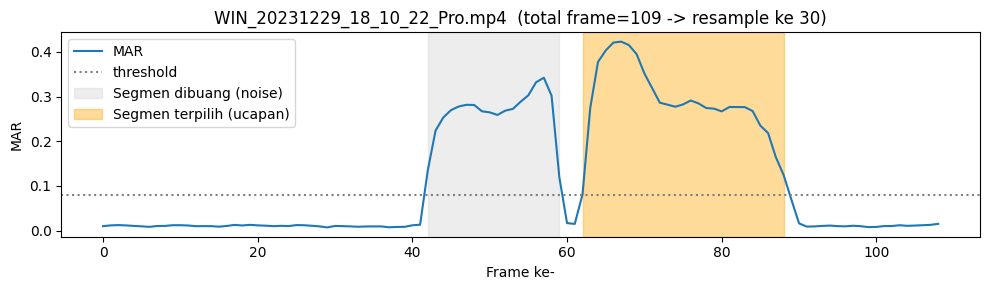

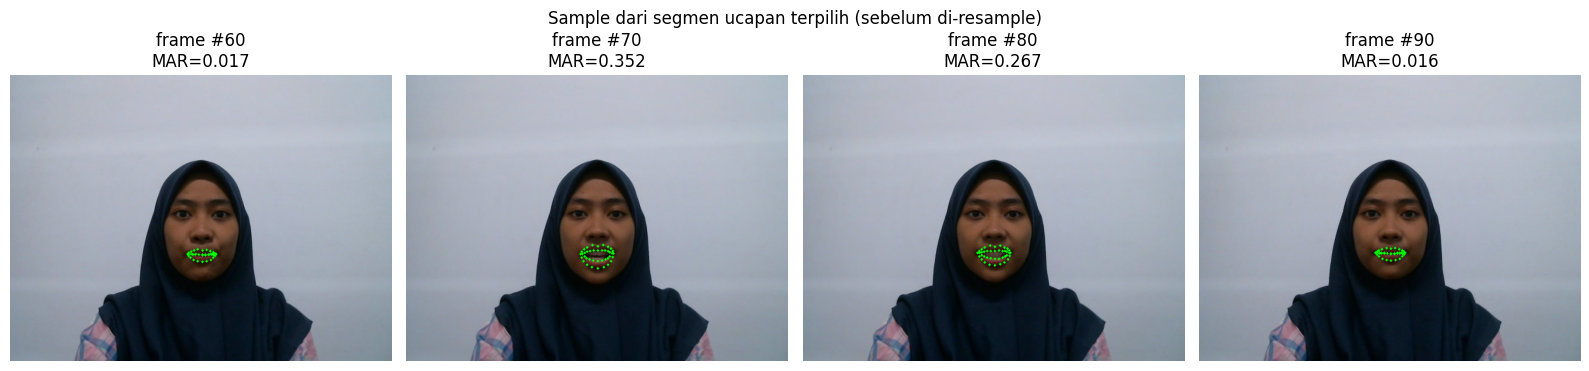

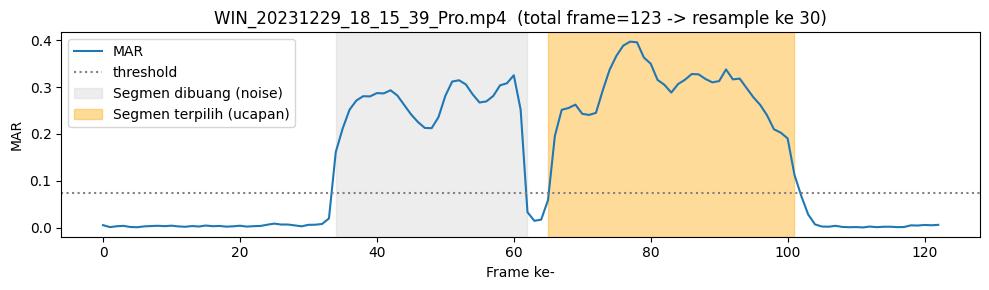

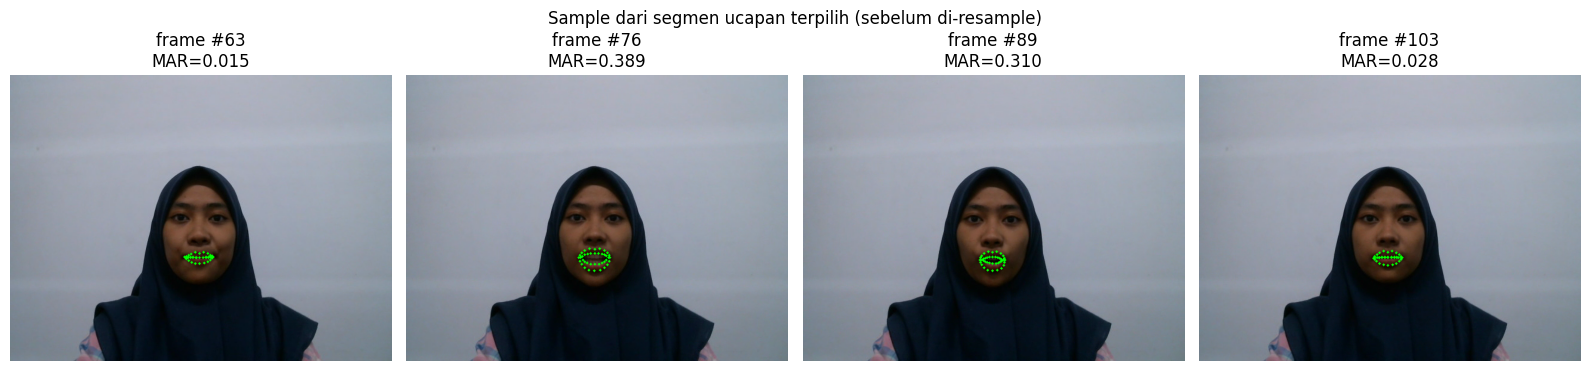

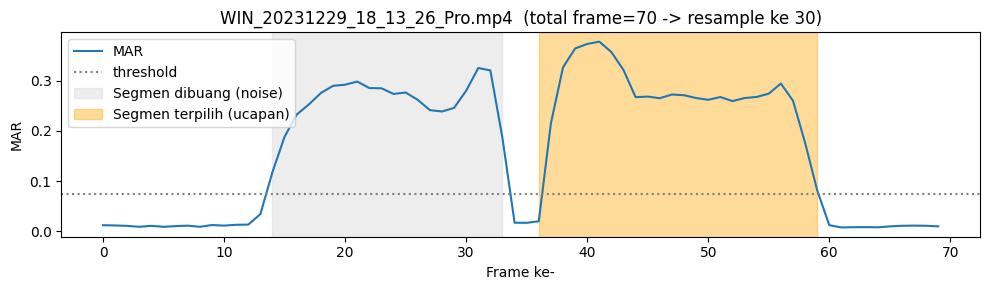

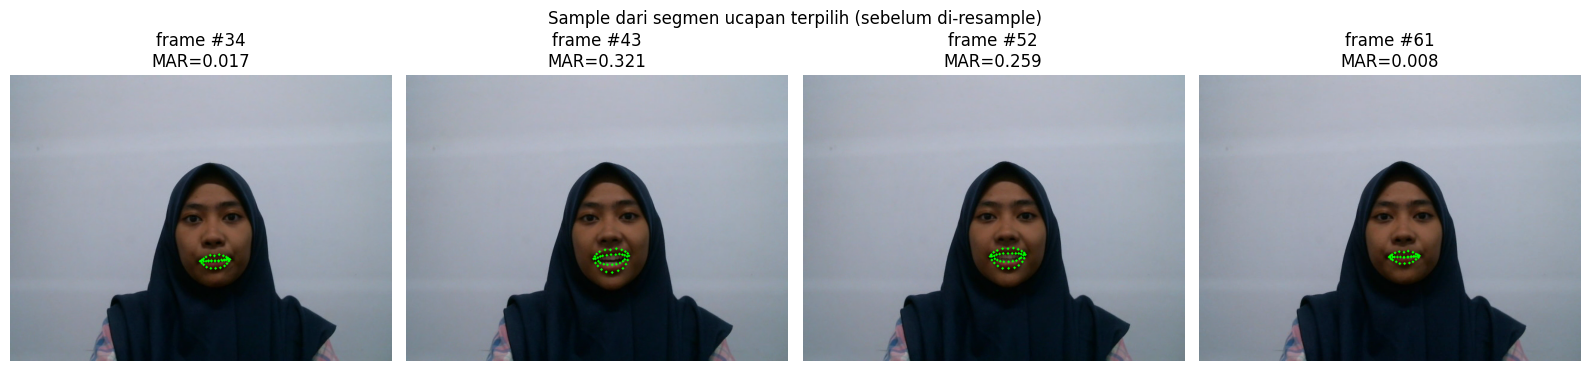

In [ ]:
# @title 2.4b Sanity check: verifikasi window aktif + landmark overlay (visual, per video)
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def get_full_mar_sequence_with_frames(video_path):
    """Re-run deteksi di SATU video utuh (tanpa windowing/pad), simpan MAR
    tiap frame + frame gambar asli, khusus untuk keperluan visualisasi sanity
    check -- bukan untuk pipeline training."""
    cap = cv2.VideoCapture(video_path)
    mars, raw_frames, lip_pts_list = [], [], []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        raw_frames.append(frame.copy())

        mar_val, lip_pts_this = None, None
        try:
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB,
                               data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            result = detector.detect(mp_img)
            if result.face_landmarks:
                landmarks = result.face_landmarks[0]
                h, w = frame.shape[:2]
                lip_pts, left_eye, right_eye = extract_raw_points(landmarks, w, h)
                normalized = normalize_frame(lip_pts, left_eye, right_eye)
                mar_val = compute_mar(normalized)
                lip_pts_this = lip_pts  # koordinat PIKSEL asli (bukan ternormalisasi), untuk digambar
        except Exception:
            pass

        mars.append(mar_val)
        lip_pts_list.append(lip_pts_this)

    cap.release()
    return mars, raw_frames, lip_pts_list


def sanity_check_video(video_path, seq_len, n_frame_samples=4):
    mars, raw_frames, lip_pts_list = get_full_mar_sequence_with_frames(video_path)
    n = len(mars)
    if n == 0:
        print(f"⚠️  GAGAL: '{video_path}' tidak menghasilkan frame.")
        return

    mar_arr = np.array([m if m is not None else np.nan for m in mars], dtype=np.float32)
    if np.isnan(mar_arr).any():
        valid = ~np.isnan(mar_arr)
        mar_arr[~valid] = np.interp(np.flatnonzero(~valid), np.flatnonzero(valid), mar_arr[valid])

    segments, threshold = find_active_segments(mar_arr)
    onset, offset = find_speech_interval(mar_arr)

    plt.figure(figsize=(10, 3))
    plt.plot(mar_arr, label="MAR")
    plt.axhline(threshold, color="gray", linestyle=":", label="threshold")

    # Tampilkan SEMUA segmen yang terdeteksi (abu-abu = dibuang, oranye = dipilih)
    for s in segments:
        is_selected = (s["start"] <= onset <= s["end"]) or (s["start"] <= offset <= s["end"]) or \
                      (onset <= s["start"] and offset >= s["end"])
        color = "orange" if is_selected else "lightgray"
        label = "Segmen terpilih (ucapan)" if is_selected else "Segmen dibuang (noise)"
        plt.axvspan(s["start"], s["end"], color=color, alpha=0.4,
                    label=label if label not in plt.gca().get_legend_handles_labels()[1] else None)

    plt.title(f"{Path(video_path).name}  (total frame={n} -> resample ke {seq_len})")
    plt.xlabel("Frame ke-"); plt.ylabel("MAR"); plt.legend()
    plt.tight_layout(); plt.show()

    sample_indices = np.linspace(onset, offset, n_frame_samples).astype(int)
    fig, axes = plt.subplots(1, n_frame_samples, figsize=(4 * n_frame_samples, 4))
    if n_frame_samples == 1: axes = [axes]
    for ax, idx in zip(axes, sample_indices):
        frame_bgr = raw_frames[idx].copy()
        lip_pts = lip_pts_list[idx]
        if lip_pts is not None:
            for (x, y) in lip_pts:
                cv2.circle(frame_bgr, (int(x), int(y)), 2, (0, 255, 0), -1)
        ax.imshow(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
        ax.set_title(f"frame #{idx}\nMAR={mar_arr[idx]:.3f}")
        ax.axis("off")
    plt.suptitle("Sample dari segmen ucapan terpilih (sebelum di-resample)")
    plt.tight_layout(); plt.show()


# --- Jalankan untuk beberapa contoh video (ganti path sesuai kebutuhan) ---
sample_videos = [
    "/content/data/1 Natural ( Lulu )/11 Terimakasih/WIN_20231229_18_10_22_Pro.mp4",   # 89 frame
    "/content/data/1 Natural ( Lulu )/12 Saya Minta Tolong/WIN_20231229_18_15_39_Pro.mp4",   # 20 frame (kasus n < seq_len)
    "/content/data/1 Natural ( Lulu )/11 Terimakasih/WIN_20231229_18_13_26_Pro.mp4",   # 128 frame (video terpanjang)
]

for vp in sample_videos:
    sanity_check_video(vp, seq_len=CONFIG["SEQ_LEN_WORD"])

In [1]:
# @title 2.5 Backup hasil preprocessing
import os
import json

# =====================================================================
# 1. TEMPEL KODE KAGGLE API TOKEN
# =====================================================================
os.environ['KAGGLE_API_TOKEN'] = "KGAT_6afe5515d17bd82946b81ff3775e4e69"

# Masukkan username asli Kaggle kamu di sini (Bisa dilihat di profil Kaggle-mu)
USERNAME_KAGGLE = "afnanimadurrosyad"

print("✓ Token dan Username berhasil dikonfigurasi!")
print("-" * 60)

# =====================================================================
# 2. ZIP DATASET AGAR TIDAK DI-SKIP
# =====================================================================
# Membuat folder penampung final untuk file zip & metadata
UPLOAD_DIR = "/content/kaggle_upload_ready"
os.makedirs(UPLOAD_DIR, exist_ok=True)

print("Sedang mengompres dataset menjadi file ZIP (biar folder gak di-skip)...")
# Mengompres semua isi dari OUT_ROOT langsung ke file zip di folder upload
!zip -r -q {UPLOAD_DIR}/dataset_siap_train.zip {CONFIG["OUT_ROOT"]}/*
print("✓ Kompresi selesai!")
print("-" * 60)

# =====================================================================
# 3. KREASI METADATA YANG VALID
# =====================================================================
!kaggle datasets init -p {UPLOAD_DIR}

metadata_path = os.path.join(UPLOAD_DIR, "dataset-metadata.json")
JUDUL_DATASET = "lipreadingv5"  # Judul dataset di Kaggle

with open(metadata_path, 'r') as f:
    meta = json.load(f)

# Menggunakan username aslimu agar tidak error Invalid Owner Id
meta['id'] = f"{USERNAME_KAGGLE}/{JUDUL_DATASET.lower()}"
meta['title'] = JUDUL_DATASET

with open(metadata_path, 'w') as f:
    json.dump(meta, f, indent=2)

print("✓ Metadata berhasil diperbaiki dengan Owner ID yang valid.")
print("-" * 60)

# =====================================================================
# 4. TERBANGKAN DATA KE KAGGLE
# =====================================================================
print("Memulai ulang transfer langsung ke Kaggle (Cloud-to-Cloud)...")
!kaggle datasets create -p {UPLOAD_DIR}

print("\n" + "="*60)
print("SELESAI! Cek akun Kaggle-mu pada bagian Datasets.")
print("Sekarang aman untuk ganti: Runtime > Change runtime type > GPU (T4)")
print("="*60)

✓ Token dan Username berhasil dikonfigurasi!
------------------------------------------------------------
Sedang mengompres dataset menjadi file ZIP (biar folder gak di-skip)...

zip error: Nothing to do! (try: zip -r -q {UPLOAD_DIR}/dataset_siap_train.zip . -i {CONFIG[OUT_ROOT]}/*)
✓ Kompresi selesai!
------------------------------------------------------------
Data package template written to: /content/kaggle_upload_ready/dataset-metadata.json
✓ Metadata berhasil diperbaiki dengan Owner ID yang valid.
------------------------------------------------------------
Memulai ulang transfer langsung ke Kaggle (Cloud-to-Cloud)...
Dataset creation error: The requested title "lipreadingv5" is already in use by a dataset. Please choose another title.

SELESAI! Cek akun Kaggle-mu pada bagian Datasets.
Sekarang aman untuk ganti: Runtime > Change runtime type > GPU (T4)


## Bagian 3 — Load Data, Model, dan Training


In [ ]:
# @title 3.1 (Jika baru ganti runtime) Ambil & Rapikan Data dari Kaggle
import os
import shutil

# 1. Install/upgrade kagglehub
!pip install --upgrade kagglehub -q
import kagglehub

# =====================================================================
# 2. KONFIGURASI API TOKEN KAGGLE
# =====================================================================
os.environ['KAGGLE_API_TOKEN'] = "KGAT_6afe5515d17bd82946b81ff3775e4e69"

# !!! PASTIKAN UBAH INI SESUAI USERNAME & JUDUL ASLI DI KAGGLE-MU !!!
USERNAME_KAGGLE = "afnanimadurrosyad"
JUDUL_DATASET = "lipreadingv5"

dataset_handle = f"{USERNAME_KAGGLE}/{JUDUL_DATASET.lower()}"

# Folder target utama yang kamu mau
OUT_ROOT = "/content/precomputed"
os.makedirs(OUT_ROOT, exist_ok=True)

try:
    print(f"Sedang mengunduh dataset '{dataset_handle}'...")
    downloaded_path = kagglehub.dataset_download(dataset_handle)

    # Jalur folder yang dobel akibat struktur zip lama
    nested_path = os.path.join(downloaded_path, "content/precomputed")

    # Cek apakah folder dobel itu ada, kalau ada kita ambil dari sana
    source_dir = nested_path if os.path.exists(nested_path) else downloaded_path

    # Pindahkan isi folder langsung ke /content/precomputed/
    for item in os.listdir(source_dir):
        s = os.path.join(source_dir, item)
        d = os.path.join(OUT_ROOT, item)
        if os.path.isdir(s):
            shutil.copytree(s, d, dirs_exist_ok=True)
        else:
            shutil.copy2(s, d)

    # Hapus sisa folder sampah bersarang jika ada agar bersih
    if os.path.exists(os.path.join(OUT_ROOT, "content")):
        shutil.rmtree(os.path.join(OUT_ROOT, "content"))

    print("\n" + "-" * 60)
    print("✓ SELESAI! Struktur folder sudah rapi!")
    print("Sekarang datamu langsung berada di:")
    # Print contoh folder untuk memastikan
    contoh_folder = [f for f in os.listdir(OUT_ROOT) if os.path.isdir(os.path.join(OUT_ROOT, f))]
    if contoh_folder:
        print(f"👉 {OUT_ROOT}/{contoh_folder[0]}")
    print("Silakan lanjut ke Bagian 3.2, bro!")
    print("-" * 60)

except Exception as e:
    print(f"\nGagal total karena: {e}")

Sedang mengunduh dataset 'afnanimadurrosyad/lipreadingv5'...


100%|██████████| 55.6M/55.6M [00:01<00:00, 56.2MB/s]

Extracting files...



------------------------------------------------------------
✓ SELESAI! Struktur folder sudah rapi!
Sekarang datamu langsung berada di:
👉 /content/precomputed/4 Halo
Silakan lanjut ke Bagian 3.2, bro!
------------------------------------------------------------


In [ ]:
# @title 3.2 CONFIG untuk training (isi ulang kalau runtime baru direstart)
import torch

CONFIG = {
    "OUT_ROOT": "/content/precomputed",
    "BATCH_SIZE": 16,
    "LEARNING_RATE": 1e-3,
    "EPOCHS": 80,
    "PATIENCE": 8,
    "SEED": 27,
    "USE_WANDB": True,   # ubah ke True kalau mau logging ke Weights & Biases
    "MODEL_NAME": "LRCN3Conv",  # pilih: "LRCN2Conv" atau "LRCN3Conv"
    "CHECKPOINT_PATH": "/content/best_model.pth",
    "DRIVE_CHECKPOINT_DIR": "/content/drive/MyDrive/IndoLR/checkpoints",
     "SEQ_LEN_WORD": 30,       # sesuai jurnal: 30 frame untuk dataset kata
    "SEQ_LEN_PHRASE": 40,     # sesuai jurnal: 40 frame untuk dataset frasa
    "TARGET_SIZE": (80, 80),  # sesuai jurnal: 80x80
    "MAX_FRAMES_READ": 400,
    "PAD_RATIO": 0.15,
    "MIN_BOX_SIZE": 20,
    "MAX_WORD_INDEX": 10,
}

os.makedirs(CONFIG["DRIVE_CHECKPOINT_DIR"], exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type != "cuda":
    print("⚠️ GPU tidak terdeteksi. Pastikan runtime sudah diganti ke GPU (T4) agar training cepat.")

Device: cuda


In [ ]:
# @title 3.3 Set random seed (reproducibility)
import numpy as np, random, torch

seed = CONFIG["SEED"]
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.cuda.manual_seed_all(seed)

In [ ]:
# @title 3.4 Dataset & DataLoader (landmark-based, speaker-independent, dgn augmentasi)
import os, glob, re
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit

DATASET_SCOPE = "words"

class LandmarkDataset(Dataset):
    def __init__(self, root, scope="all", max_word_index=None, augment=False):
        self.samples, self.speakers, self.classes = [], [], []
        self.augment = augment
        folders = []

        for name in sorted(os.listdir(root)):
            path = os.path.join(root, name)
            if not os.path.isdir(path): continue
            m = re.match(r'^\s*(\d+)\s+(.*)$', name)
            if not m: continue
            idx, word = int(m.group(1)), m.group(2).strip()
            if scope == "words" and idx > max_word_index: continue
            if scope == "phrases" and idx <= max_word_index: continue
            folders.append((idx, word, path))
        folders.sort(key=lambda x: x[0])

        for _, word, path in folders:
            if word not in self.classes:
                self.classes.append(word)
            label = self.classes.index(word)
            for f in glob.glob(os.path.join(path, "*.npy")):
                fname = os.path.basename(f)
                speaker = fname.split("__")[0] if "__" in fname else "unknown"
                self.samples.append((f, label))
                self.speakers.append(speaker)

        if len(self.samples) == 0:
            raise RuntimeError(f"Tidak ada data untuk scope='{scope}'.")

    def __len__(self):
        return len(self.samples)

    def _augment(self, arr):
        """Augmentasi RINGAN di ruang koordinat (bukan piksel) -- jauh lebih
        murah & tidak mengubah identitas geometris kata, cuma menambah variasi
        kecil supaya model tidak hafal noise deteksi/skala eksak.
        Hanya dipanggil kalau self.augment=True (mode training)."""
        T, D = arr.shape
        out = arr.copy()

        # 1) Jitter skala kecil (simulasi variasi jarak kamera residual)
        scale = np.random.uniform(0.95, 1.05)
        out[:, :-1] *= scale  # kolom terakhir = MAR, jangan ikut di-scale linear ini

        # 2) Jitter rotasi kecil (residual head-tilt yang tak sepenuhnya terkoreksi)
        angle = np.deg2rad(np.random.uniform(-4, 4))
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        rot = np.array([[cos_a, -sin_a], [sin_a, cos_a]], dtype=np.float32)
        coords = out[:, :-1].reshape(T, -1, 2)
        coords = coords @ rot.T
        out[:, :-1] = coords.reshape(T, -1)

        # 3) Gaussian noise kecil pada koordinat (simulasi noise deteksi landmark)
        noise = np.random.normal(0, 0.01, size=out[:, :-1].shape).astype(np.float32)
        out[:, :-1] += noise

        # 4) Time-jitter ringan: kadang ulang/skip 1 frame acak (simulasi variasi kecepatan bicara)
        if np.random.rand() < 0.3 and T > 4:
            i = np.random.randint(1, T - 1)
            out = np.delete(out, i, axis=0)
            out = np.vstack([out, out[-1:]])  # ganti dengan duplikasi frame terakhir

        return out.astype(np.float32)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        arr = np.load(path)  # (T, D)
        if self.augment:
            arr = self._augment(arr)
        return torch.from_numpy(arr), label


class _SubsetByIndices(Dataset):
    def __init__(self, dataset, indices, augment=False):
        self.dataset = dataset
        self.indices = list(indices)
        self.augment = augment  # override augment behaviour per-subset

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        real_idx = self.indices[i]
        path, label = self.dataset.samples[real_idx]
        arr = np.load(path)
        if self.augment:
            arr = self.dataset._augment(arr)
        return torch.from_numpy(arr).float(), label


dataset = LandmarkDataset(root=CONFIG["OUT_ROOT"], scope=DATASET_SCOPE,
                           max_word_index=CONFIG["MAX_WORD_INDEX"])
print(f"Scope: {DATASET_SCOPE} | Kelas ({len(dataset.classes)}): {dataset.classes}")

speakers = np.array(dataset.speakers)
labels = np.array([lbl for _, lbl in dataset.samples])

gss1 = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=CONFIG["SEED"])
train_idx, temp_idx = next(gss1.split(np.zeros(len(dataset)), labels, groups=speakers))
temp_speakers, temp_labels = speakers[temp_idx], labels[temp_idx]
gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=CONFIG["SEED"])
val_rel, test_rel = next(gss2.split(np.zeros(len(temp_idx)), temp_labels, groups=temp_speakers))
val_idx, test_idx = temp_idx[val_rel], temp_idx[test_rel]

# Augmentasi HANYA di train, val/test tetap bersih (data asli, tanpa augmentasi)
train_ds = _SubsetByIndices(dataset, train_idx, augment=True)
val_ds   = _SubsetByIndices(dataset, val_idx,   augment=False)
test_ds  = _SubsetByIndices(dataset, test_idx,  augment=False)

print("Speaker train:", sorted(set(speakers[train_idx])))
print("Speaker val  :", sorted(set(speakers[val_idx])))
print("Speaker test :", sorted(set(speakers[test_idx])))

train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=2)
print("Total:", len(dataset), "Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

Scope: words | Kelas (10): ['Maaf', 'Tolong', 'Permisi', 'Halo', 'Mulai', 'Berhenti', 'Lanjut', 'Sakit', 'Kembali', 'Awas']
Speaker train: [np.str_('1_Natural_Lulu'), np.str_('2_Pointy_Natural_Sandy'), np.str_('4_Thin_Jelly'), np.str_('5_Unilip_brrr'), np.str_('6_Bestung_-_intan'), np.str_('7_Smear_Indra')]
Speaker val  : [np.str_('8_Glamor_Bella')]
Speaker test : [np.str_('3_Cupids_Bow_Grace')]
Total: 4153 Train: 3153 Val: 500 Test: 500


### 3.4b — Distribusi sample per kelas & sanity check visual preprocessing

Dua hal ini WAJIB dicek sebelum training:
1. **Distribusi jumlah sample per kata** — kalau timpang jauh, model bisa collapse ke kelas mayoritas (persis masalah yang pernah terjadi sebelumnya).
2. **Visual hasil crop 80x80** — memastikan bounding box bibir benar-benar pas (tidak kepotong, tidak terlalu lebar/sempit) *sebelum* buang waktu training penuh. Ini langkah yang kalau ada dari awal, bug mismatch bbox pada prototipe sebelumnya akan langsung kelihatan dari gambar, bukan baru ketahuan saat live-inference selalu memprediksi satu kelas.

,train,val,test,total
Maaf,314,50,50,414
Tolong,311,50,50,411
Permisi,328,50,50,428
Halo,315,50,50,415
Mulai,311,50,50,411
Berhenti,308,50,50,408
Lanjut,325,50,50,425
Sakit,309,50,50,409
Kembali,317,50,50,417
Awas,315,50,50,415


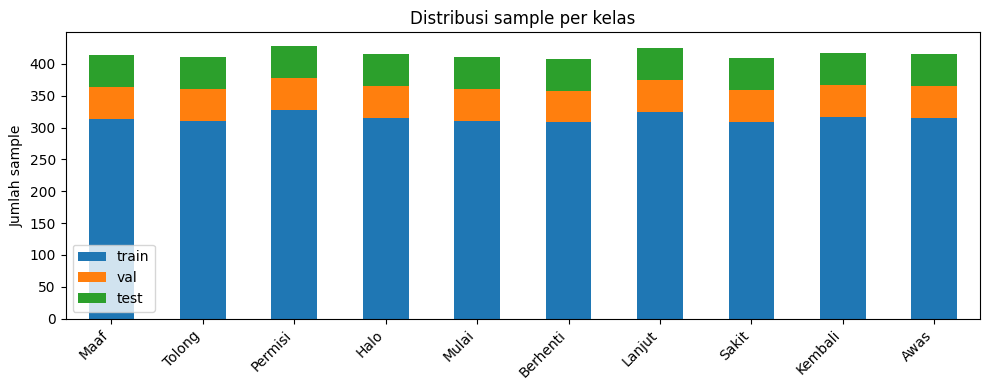

Rasio ketimpangan (kelas terbanyak / kelas tersedikit): 1.05x


In [ ]:
# @title 3.4b Distribusi sample per kelas (train/val/test)
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

def count_per_class(subset, classes):
    counter = Counter()
    for _, label in [subset.dataset.samples[i] if hasattr(subset, "dataset") else subset.samples[i] for i in (subset.indices if hasattr(subset, "indices") else range(len(subset)))]:
        counter[classes[label]] += 1
    return counter

train_counts = count_per_class(train_ds, dataset.classes)
val_counts = count_per_class(val_ds, dataset.classes)
test_counts = count_per_class(test_ds, dataset.classes)

df_dist = pd.DataFrame({
    "train": [train_counts.get(c, 0) for c in dataset.classes],
    "val": [val_counts.get(c, 0) for c in dataset.classes],
    "test": [test_counts.get(c, 0) for c in dataset.classes],
}, index=dataset.classes)
df_dist["total"] = df_dist.sum(axis=1)
display(df_dist)

df_dist[["train", "val", "test"]].plot(kind="bar", stacked=True, figsize=(10, 4))
plt.title("Distribusi sample per kelas")
plt.ylabel("Jumlah sample")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

imbalance_ratio = df_dist["total"].max() / df_dist["total"].min()
print(f"Rasio ketimpangan (kelas terbanyak / kelas tersedikit): {imbalance_ratio:.2f}x")
if imbalance_ratio > 2:
    print("PERINGATAN: ketimpangan cukup besar -- pertimbangkan class weighting (sel 3.4c) atau tambah data kelas minoritas.")


In [ ]:
# @title 3.4d (Opsional) Class weighting untuk CrossEntropyLoss
# Berguna kalau rasio ketimpangan di sel 3.4b > ~2x (terutama setelah menggabungkan
# data hasil LIRA-Gen yang distribusinya tidak akan serapi IndoLR).
import torch as _torch

class_counts = _torch.tensor([train_counts.get(c, 1) for c in dataset.classes], dtype=_torch.float)
class_weights = class_counts.sum() / (len(dataset.classes) * class_counts)
class_weights = class_weights.to(device)
print("Class weights:", {c: round(w.item(), 3) for c, w in zip(dataset.classes, class_weights)})

CONFIG["USE_CLASS_WEIGHTS"] = True  # set False untuk kembali ke CrossEntropyLoss tanpa weighting


Class weights: {'Maaf': 1.015, 'Tolong': 1.078, 'Permisi': 0.94, 'Halo': 0.958, 'Mulai': 1.029, 'Berhenti': 1.04, 'Lanjut': 0.984, 'Sakit': 1.001, 'Kembali': 0.981, 'Awas': 0.991}


In [ ]:
# @title 3.5 Model: BiGRU untuk fitur landmark (disesuaikan dengan pipeline resampling terbaru)
import torch
import torch.nn as nn


class LipLandmarkBiGRU(nn.Module):
    """Model untuk sequence landmark hasil pipeline TERBARU (deteksi segmen
    ucapan via MAR + resampling interpolasi ke seq_len tetap -- BUKAN lagi
    crop/pad seperti versi sebelumnya).

    Implikasi desain:
    - Tidak ada lagi zero-padding di sequence, jadi seluruh timestep sama-sama
      valid (representasi hasil interpolasi dari rentang ucapan asli).
    - Attention pooling tetap dipakai, tapi alasannya sekarang murni untuk
      membiarkan model belajar bobot lebih tinggi ke frame yang paling
      diskriminatif (biasanya di sekitar puncak artikulasi/MAR tinggi),
      dibanding frame transisi (onset membuka/offset menutup mulut) yang
      cenderung mirip antar kata.
    - Conv1D kecil di depan GRU (opsional, default aktif) membantu menangkap
      pola LOKAL antar-frame berdekatan (semacam 'kecepatan gerak') sebelum
      diteruskan ke GRU yang menangkap pola jangka panjang.
    """

    def __init__(self, num_classes, input_dim=TARGET_SEQ_FEATURE_DIM,
                 hidden_size=96, num_layers=1, dropout=0.4,
                 use_conv_frontend=True, conv_channels=64):
        super().__init__()
        self.use_conv_frontend = use_conv_frontend
        self.input_norm = nn.LayerNorm(input_dim)

        if use_conv_frontend:
            # Conv1D kecil sepanjang waktu (kernel=3) untuk menangkap
            # perubahan lokal antar-frame berdekatan sebelum GRU.
            # Padding='same' via padding=1 supaya panjang sequence tidak berubah.
            self.conv_frontend = nn.Sequential(
                nn.Conv1d(input_dim, conv_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Dropout(dropout * 0.5),
            )
            gru_input_dim = conv_channels
        else:
            self.conv_frontend = None
            gru_input_dim = input_dim

        self.gru = nn.GRU(
            input_size=gru_input_dim, hidden_size=hidden_size, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # Attention pooling: bobot per-timestep dipelajari, supaya model bisa
        # fokus otomatis ke bagian sequence yang paling diskriminatif untuk
        # klasifikasi (mis. puncak artikulasi), bukan cuma titik akhir sequence.
        self.attn = nn.Linear(hidden_size * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # x: (B, T, D)
        x = self.input_norm(x)

        if self.use_conv_frontend:
            x = x.transpose(1, 2)          # (B, D, T) -- Conv1d butuh channel di dim ke-2
            x = self.conv_frontend(x)      # (B, conv_channels, T)
            x = x.transpose(1, 2)          # (B, T, conv_channels)

        out, _ = self.gru(x)                       # (B, T, 2*hidden)
        scores = self.attn(out).squeeze(-1)         # (B, T)
        weights = torch.softmax(scores, dim=1)      # (B, T)
        pooled = torch.sum(out * weights.unsqueeze(-1), dim=1)  # (B, 2*hidden)

        return self.fc(self.dropout(pooled))


# Instansiasi model
model = LipLandmarkBiGRU(
    num_classes=len(dataset.classes),
    input_dim=TARGET_SEQ_FEATURE_DIM,
    hidden_size=96,
    num_layers=1,
    dropout=0.4,
    use_conv_frontend=True,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model: LipLandmarkBiGRU | Total parameter: {n_params:,}")
print(model)

Model: LipLandmarkBiGRU | Total parameter: 111,213
LipLandmarkBiGRU(
  (input_norm): LayerNorm((81,), eps=1e-05, elementwise_affine=True)
  (conv_frontend): Sequential(
    (0): Conv1d(81, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (gru): GRU(64, 96, batch_first=True, bidirectional=True)
  (attn): Linear(in_features=192, out_features=1, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=192, out_features=10, bias=True)
)


In [ ]:
# @title 3.6 (Opsional) Login Weights & Biases untuk logging training
# 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
if CONFIG["USE_WANDB"]:
    !pip install -q wandb
    import wandb
    wandb.login()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 6.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.4.2 which is incompatible.


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: afnanimadurrosyad911 (afnanimadurrosyad) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


LOSO akan dijalankan untuk 8 fold (speaker): ['1_Natural_Lulu', '2_Pointy_Natural_Sandy', '3_Cupids_Bow_Grace', '4_Thin_Jelly', '5_Unilip_brrr', '6_Bestung_-_intan', '7_Smear_Indra', '8_Glamor_Bella']

FOLD 1/8  |  Held-out (test) speaker: 1_Natural_Lulu
  Train speakers (6): [np.str_('2_Pointy_Natural_Sandy'), np.str_('4_Thin_Jelly'), np.str_('5_Unilip_brrr'), np.str_('6_Bestung_-_intan'), np.str_('7_Smear_Indra'), np.str_('8_Glamor_Bella')]
  Val speakers   (1): [np.str_('3_Cupids_Bow_Grace')]
  Test speaker   : 1_Natural_Lulu
  N train=3115  N val=500  N test=538
  Epoch  1/80 | train_acc=0.145 val_acc=0.156 | train_loss=2.222 val_loss=2.207  <-- best
  Epoch  2/80 | train_acc=0.271 val_acc=0.302 | train_loss=1.919 val_loss=1.790  <-- best
  Epoch  3/80 | train_acc=0.378 val_acc=0.296 | train_loss=1.677 val_loss=1.812  <-- best
  Epoch  4/80 | train_acc=0.506 val_acc=0.490 | train_loss=1.366 val_loss=1.810  <-- best
  Epoch  5/80 | train_acc=0.619 val_acc=0.374 | train_loss=1.089 va

,fold,test_speaker,best_epoch,best_val_loss,test_acc,test_f1_macro,n_train,n_val,n_test
0,1,1_Natural_Lulu,12,1.763045,0.457249,0.405055,3115,500,538
1,2,2_Pointy_Natural_Sandy,1,2.073865,0.218000,0.180765,3153,500,500
2,3,3_Cupids_Bow_Grace,4,1.890756,0.416000,0.368912,3152,501,500
3,4,4_Thin_Jelly,26,1.334366,0.398000,0.324185,3077,576,500
4,5,5_Unilip_brrr,5,1.632471,0.327345,0.312201,3114,538,501
5,6,6_Bestung_-_intan,10,1.314946,0.545139,0.509611,3077,500,576
6,7,7_Smear_Indra,25,1.789480,0.340149,0.302007,3077,538,538
7,8,8_Glamor_Bella,12,1.986223,0.540000,0.537452,3153,500,500



RINGKASAN LOSO
Rata-rata test accuracy : 0.4052  (std=0.1108)
Rata-rata test F1-macro : 0.3675  (std=0.1162)
Rentang akurasi         : 0.2180 - 0.5451


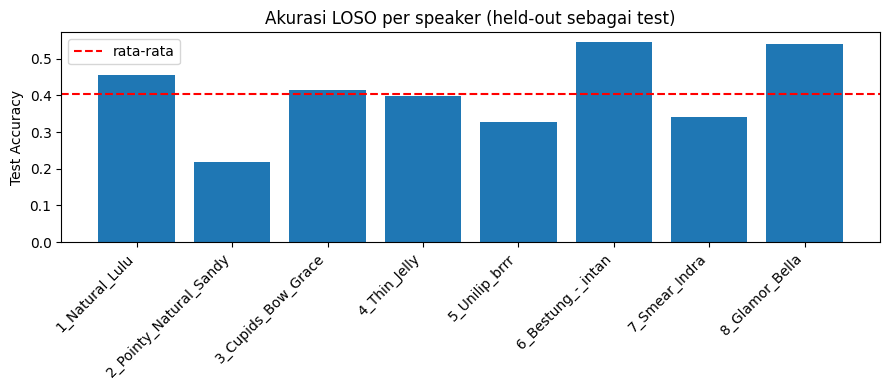

In [ ]:
# @title 3.7 Leave-One-Speaker-Out Cross-Validation (LOSO)
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score

# ------------------------------------------------------------------
# Konfigurasi LOSO
# ------------------------------------------------------------------
LOSO_MAX_EPOCHS = 80      # lebih pendek dari training utama (80) -- LOSO dijalankan
                          # berkali-kali jadi perlu lebih hemat waktu; early stopping
                          # tetap yang menentukan epoch efektif
LOSO_PATIENCE = 12         # early stopping: berhenti kalau val_loss tak membaik
                          # selama N epoch berturut-turut
LOSO_VAL_FRACTION_SPEAKERS = 1  # jumlah speaker (dari sisa train) yang disisihkan
                                 # jadi val internal tiap fold, untuk early stopping

all_speakers = sorted(set(dataset.speakers))
print(f"LOSO akan dijalankan untuk {len(all_speakers)} fold (speaker): {all_speakers}")

fold_results = []
fold_histories = {}

for fold_i, held_out_speaker in enumerate(all_speakers, start=1):
    print("\n" + "=" * 70)
    print(f"FOLD {fold_i}/{len(all_speakers)}  |  Held-out (test) speaker: {held_out_speaker}")
    print("=" * 70)

    speakers_arr = np.array(dataset.speakers)
    labels_arr = np.array([lbl for _, lbl in dataset.samples])

    test_mask = speakers_arr == held_out_speaker
    remaining_speakers = [s for s in all_speakers if s != held_out_speaker]

    # Dari speaker yang TERSISA (bukan held-out), sisihkan sebagian sebagai
    # val internal (untuk early stopping / pilih best epoch), sisanya untuk train.
    remaining_mask = ~test_mask
    remaining_idx = np.where(remaining_mask)[0]
    rem_speakers = speakers_arr[remaining_idx]
    rem_labels = labels_arr[remaining_idx]

    n_val_speakers = max(1, LOSO_VAL_FRACTION_SPEAKERS)
    unique_rem = sorted(set(rem_speakers))
    if len(unique_rem) <= n_val_speakers:
        raise RuntimeError("Terlalu sedikit speaker tersisa untuk membentuk val internal.")

    val_speakers = unique_rem[fold_i % len(unique_rem) : fold_i % len(unique_rem) + n_val_speakers]
    if len(val_speakers) < n_val_speakers:
        val_speakers = unique_rem[: n_val_speakers]  # wrap-around sederhana

    val_mask_local = np.isin(rem_speakers, val_speakers)
    train_idx = remaining_idx[~val_mask_local]
    val_idx = remaining_idx[val_mask_local]
    test_idx = np.where(test_mask)[0]

    print(f"  Train speakers ({len(unique_rem) - len(val_speakers)}): "
          f"{[s for s in unique_rem if s not in val_speakers]}")
    print(f"  Val speakers   ({len(val_speakers)}): {val_speakers}")
    print(f"  Test speaker   : {held_out_speaker}")
    print(f"  N train={len(train_idx)}  N val={len(val_idx)}  N test={len(test_idx)}")

    train_ds_fold = _SubsetByIndices(dataset, train_idx, augment=False)   # <-- augmentasi aktif
    val_ds_fold = _SubsetByIndices(dataset, val_idx, augment=False)      # tetap bersih
    test_ds_fold = _SubsetByIndices(dataset, test_idx, augment=False)

    pin = (device.type == "cuda")
    train_loader_fold = DataLoader(train_ds_fold, batch_size=CONFIG["BATCH_SIZE"], shuffle=True, num_workers=2, pin_memory=pin)
    val_loader_fold = DataLoader(val_ds_fold, batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=2, pin_memory=pin)
    test_loader_fold = DataLoader(test_ds_fold, batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=2, pin_memory=pin)

    # ------------------------------------------------------------------
    # Model & optimizer baru dari NOL tiap fold (tidak boleh reuse weight
    # dari fold sebelumnya, supaya tiap fold benar-benar independen)
    # ------------------------------------------------------------------
    model_fold = LipLandmarkBiGRU(num_classes=len(dataset.classes)).to(device)
    criterion = nn.CrossEntropyLoss() #label_smoothing=0.1
    optimizer = optim.Adam(model_fold.parameters(), lr=CONFIG.get("LEARNING_RATE", 0.0005))

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, LOSO_MAX_EPOCHS + 1):
        # ---- Train ----
        model_fold.train()
        run_loss, run_correct, run_n = 0.0, 0, 0
        for xb, yb in train_loader_fold:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model_fold(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * xb.size(0)
            run_correct += (out.argmax(1) == yb).sum().item()
            run_n += xb.size(0)
        train_loss = run_loss / run_n
        train_acc = run_correct / run_n

        # ---- Val ----
        model_fold.eval()
        v_loss, v_correct, v_n = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader_fold:
                xb, yb = xb.to(device), yb.to(device)
                out = model_fold(xb)
                loss = criterion(out, yb)
                v_loss += loss.item() * xb.size(0)
                v_correct += (out.argmax(1) == yb).sum().item()
                v_n += xb.size(0)
        val_loss = v_loss / v_n
        val_acc = v_correct / v_n

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        smoothed_val_loss = np.mean(history["val_loss"][-3:])
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        improved = smoothed_val_loss < best_val_loss
        if improved:
            best_val_loss = smoothed_val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model_fold.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"  Epoch {epoch:2d}/{LOSO_MAX_EPOCHS} | train_acc={train_acc:.3f} val_acc={val_acc:.3f} "
              f"| train_loss={train_loss:.3f} val_loss={val_loss:.3f}"
              f"{'  <-- best' if improved else ''}")

        if epochs_no_improve >= LOSO_PATIENCE:
            print(f"  Early stopping di epoch {epoch} (tidak membaik selama {LOSO_PATIENCE} epoch).")
            break

    # ------------------------------------------------------------------
    # Evaluasi di TEST speaker pakai bobot terbaik (berdasarkan val internal)
    # ------------------------------------------------------------------
    model_fold.load_state_dict(best_state)
    model_fold.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in test_loader_fold:
            xb = xb.to(device)
            out = model_fold(xb)
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(yb.numpy())

    test_acc = np.mean(np.array(all_preds) == np.array(all_true))
    test_f1_macro = f1_score(all_true, all_preds, average="macro")

    print(f"  >> Test ({held_out_speaker}): acc={test_acc:.4f}  f1_macro={test_f1_macro:.4f}  "
          f"(best_epoch={best_epoch}, best_val_loss={best_val_loss:.4f})")

    fold_results.append({
        "fold": fold_i,
        "test_speaker": held_out_speaker,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "test_acc": test_acc,
        "test_f1_macro": test_f1_macro,
        "n_train": len(train_idx),
        "n_val": len(val_idx),
        "n_test": len(test_idx),
    })
    fold_histories[held_out_speaker] = history

# ------------------------------------------------------------------
# Ringkasan hasil LOSO
# ------------------------------------------------------------------
df_loso = pd.DataFrame(fold_results)
display(df_loso)

print("\n" + "=" * 70)
print("RINGKASAN LOSO")
print("=" * 70)
print(f"Rata-rata test accuracy : {df_loso['test_acc'].mean():.4f}  (std={df_loso['test_acc'].std():.4f})")
print(f"Rata-rata test F1-macro : {df_loso['test_f1_macro'].mean():.4f}  (std={df_loso['test_f1_macro'].std():.4f})")
print(f"Rentang akurasi         : {df_loso['test_acc'].min():.4f} - {df_loso['test_acc'].max():.4f}")

# Visualisasi akurasi per speaker (fold)
plt.figure(figsize=(9, 4))
plt.bar(df_loso["test_speaker"], df_loso["test_acc"])
plt.axhline(df_loso["test_acc"].mean(), color="red", linestyle="--", label="rata-rata")
plt.ylabel("Test Accuracy")
plt.title("Akurasi LOSO per speaker (held-out sebagai test)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# @title 3.7 Training loop (dengan validasi, early stopping, checkpoint terbaik, per-kelas tracking)
import time
import numpy as np
from sklearn.metrics import accuracy_score

def train_model():
    model_cls = MODEL_REGISTRY[CONFIG["MODEL_NAME"]]
    model = model_cls(num_classes=len(dataset.classes)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["LEARNING_RATE"])

    if CONFIG.get("USE_CLASS_WEIGHTS", False):
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()

    use_wandb = CONFIG["USE_WANDB"]
    if use_wandb:
        import wandb
        wandb.init(
            project="Lipreading-LRCN",
            name=f"{CONFIG['MODEL_NAME']}-{int(time.time())}-v3",
            config={**CONFIG, "num_classes": len(dataset.classes), "classes": dataset.classes}
        )
        wandb.watch(model, log="all", log_freq=100)

    best_val_acc = 0.0
    patience_counter = 0
    history = []

    for epoch in range(CONFIG["EPOCHS"]):
        model.train()
        total_loss, train_correct, train_total = 0.0, 0, 0

        for batch_idx, (x, y) in enumerate(train_loader):
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred = logits.argmax(dim=1)
            train_correct += (pred == y).sum().item()
            train_total += y.size(0)

        train_acc = train_correct / train_total
        train_loss = total_loss / len(train_loader)

        # Validasi -- sekalian kumpulkan prediksi per-kelas
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        val_preds_all, val_labels_all = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                val_loss += loss.item()
                pred = logits.argmax(dim=1)
                val_correct += (pred == y).sum().item()
                val_total += y.size(0)
                val_preds_all.extend(pred.cpu().numpy())
                val_labels_all.extend(y.cpu().numpy())

        val_acc = val_correct / val_total
        val_loss = val_loss / len(val_loader)

        # --- Per-class validation accuracy: deteksi dini kalau model collapse ke 1 kelas ---
        val_preds_all = np.array(val_preds_all)
        val_labels_all = np.array(val_labels_all)
        per_class_acc = {}
        collapsed_classes = []
        for class_idx, class_name in enumerate(dataset.classes):
            mask = val_labels_all == class_idx
            if mask.sum() > 0:
                acc_c = (val_preds_all[mask] == class_idx).mean()
                per_class_acc[class_name] = acc_c
                if acc_c == 0.0:
                    collapsed_classes.append(class_name)

        print(f"Epoch {epoch+1:3d}/{CONFIG['EPOCHS']} | "
              f"Train Loss={train_loss:.4f} Acc={train_acc:.2%} | "
              f"Val Loss={val_loss:.4f} Acc={val_acc:.2%}")
        if collapsed_classes:
            print(f"  PERINGATAN: akurasi 0% untuk kelas: {collapsed_classes} -- kemungkinan model collapse/imbalance.")

        log_entry = {
            "epoch": epoch + 1, "train_loss": train_loss, "train_acc": train_acc,
            "val_loss": val_loss, "val_acc": val_acc,
        }
        history.append(log_entry)

        if use_wandb:
            wandb_log = dict(log_entry)
            wandb_log.update({f"val_acc_{c}": a for c, a in per_class_acc.items()})
            wandb.log(wandb_log)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save({
                "epoch": epoch,
                "model_name": CONFIG["MODEL_NAME"],
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_acc": val_acc,
                "classes": dataset.classes,
                # Simpan konfigurasi preprocessing di dalam checkpoint itu sendiri --
                # supaya script inference/mobile di masa depan bisa BACA formula ini,
                # bukan menyalin manual dan berisiko typo/skew seperti sebelumnya.
                "preprocess_config": {
                    "version": CONFIG.get("PREPROCESS_VERSION"),
                    "target_size": CONFIG["TARGET_SIZE"],
                    "seq_len_word": CONFIG["SEQ_LEN_WORD"],
                    "pad_ratio": CONFIG["PAD_RATIO"],
                    "min_box_size": CONFIG["MIN_BOX_SIZE"],
                },
            }, CONFIG["CHECKPOINT_PATH"])
            print(f"  Model terbaik disimpan (Val Acc = {val_acc:.2%})")
        else:
            patience_counter += 1
            print(f"  Patience: {patience_counter}/{CONFIG['PATIENCE']}")

        if patience_counter >= CONFIG["PATIENCE"]:
            print("Early stopping triggered!")
            break

    if use_wandb:
        wandb.finish()

    return model, history


model, history = train_model()


Epoch   1/80 | Train Loss=2.3137 Acc=9.83% | Val Loss=2.3043 Acc=11.40%
  PERINGATAN: akurasi 0% untuk kelas: ['Maaf', 'Tolong', 'Permisi', 'Halo', 'Berhenti', 'Lanjut', 'Sakit', 'Kembali'] -- kemungkinan model collapse/imbalance.
  Model terbaik disimpan (Val Acc = 11.40%)
Epoch   2/80 | Train Loss=2.2802 Acc=13.70% | Val Loss=2.3063 Acc=8.60%
  PERINGATAN: akurasi 0% untuk kelas: ['Maaf', 'Permisi', 'Mulai', 'Berhenti', 'Lanjut', 'Sakit', 'Awas'] -- kemungkinan model collapse/imbalance.
  Patience: 1/8
Epoch   3/80 | Train Loss=2.1237 Acc=20.77% | Val Loss=2.1981 Acc=12.40%
  PERINGATAN: akurasi 0% untuk kelas: ['Maaf', 'Tolong', 'Mulai', 'Kembali'] -- kemungkinan model collapse/imbalance.
  Model terbaik disimpan (Val Acc = 12.40%)
Epoch   4/80 | Train Loss=1.9022 Acc=29.15% | Val Loss=2.1305 Acc=19.00%
  PERINGATAN: akurasi 0% untuk kelas: ['Maaf', 'Tolong', 'Mulai', 'Sakit', 'Kembali'] -- kemungkinan model collapse/imbalance.
  Model terbaik disimpan (Val Acc = 19.00%)
Epoch   5/8

epoch,▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
train_acc,▁▁▂▃▄▅▆▆▇▇▇███████
train_loss,██▇▇▆▅▄▃▃▂▂▂▁▁▁▁▁▁
val_acc,▂▁▂▄▃▃▄▅▆█▅▄▆▆▇▇▆▆
val_acc_Awas,█▁▂▄▅▁▂▅▆▇▆▄▃▅▆▅▃▄
val_acc_Berhenti,▁▁▄▃▁▁▁▁▁█▁▁▅▄▄▁▃▄
val_acc_Halo,▁▁▇▇██████████████
val_acc_Kembali,▁█▁▁▁▁▁▁▁▁▁▁▁▁▃▃▁▂
val_acc_Lanjut,▁▁▇▇▁▁▁▁▁▄▁▁▅█▄▄▂▂
val_acc_Maaf,▁▁▁▁▁▃▆▇█▇▃▅▆▄▆▆▆▅
+5,...


In [ ]:
# @title Cetak Rangkuman Training (Run Summary)
import time

# Pastikan training sudah selesai dan variabel 'history' sudah ada
if 'history' in locals() and len(history) > 0:

    # 1. Cari epoch terbaik berdasarkan Val Accuracy tertinggi
    val_accuracies = [log['val_acc'] for log in history]
    best_idx = val_accuracies.index(max(val_accuracies))
    best_log = history[best_idx]
    best_epoch = best_log['epoch']

    # 2. Hitung perkiraan waktu jika ada log waktu (atau gunakan data statis)
    # Catatan: Jika ingin menghitung menit presisi sejak start_time,
    # cell ini harus dijalankan langsung setelah training.

    print("="*60)
    print("                    TRAINING RUN SUMMARY                    ")
    print("="*60)
    print(f"Model Name         : {CONFIG.get('MODEL_NAME', 'Unknown')}")
    print(f"Total Epochs Run   : {len(history)}/{CONFIG.get('EPOCHS', 'N/A')}")
    print(f"Best Epoch         : Epoch {best_epoch}")
    print(f"Checkpoint Saved To: {CONFIG.get('CHECKPOINT_PATH', 'N/A')}")
    print("-"*60)

    print("Final Performance (At Best Epoch):")
    print(f"  - Train Loss     : {best_log['train_loss']:.4f}")
    print(f"  - Train Accuracy : {best_log['train_acc']:.2%}")
    print(f"  - Val Loss       : {best_log['val_loss']:.4f}")
    print(f"  - Val Accuracy   : {best_log['val_acc']:.2%}")
    print("-"*60)

    # 3. Cetak akurasi per kelas dari epoch terbaik
    if 'per_class_acc' in best_log:
        print("Validation Accuracy Per-Class (At Best Epoch):")
        for class_name, acc in best_log['per_class_acc'].items():
            print(f"  * {class_name:<20}: {acc:.2%}")
    elif 'dataset' in locals():
        # Antisipasi jika objek per_class_acc tidak tersimpan di history lama
        print("Validation Accuracy Per-Class (At Best Epoch):")
        print("  [Info] Jalankan ulang training dengan update return history terbaru")

    print("="*60)

else:
    print("❌ Error: Variabel 'history' tidak ditemukan atau training belum berjalan.")

                    TRAINING RUN SUMMARY                    
Model Name         : LRCN3Conv
Total Epochs Run   : 18/80
Best Epoch         : Epoch 10
Checkpoint Saved To: /content/best_model.pth
------------------------------------------------------------
Final Performance (At Best Epoch):
  - Train Loss     : 0.5201
  - Train Accuracy : 83.70%
  - Val Loss       : 2.8827
  - Val Accuracy   : 32.80%
------------------------------------------------------------
Validation Accuracy Per-Class (At Best Epoch):
  [Info] Jalankan ulang training dengan update return history terbaru


### Code untuk membuat plot di bawah belum disesuaikan untuk penggunaan loso diatas, dan masih template default untuk hasil latihan sebuah model dengan non-LOSO.

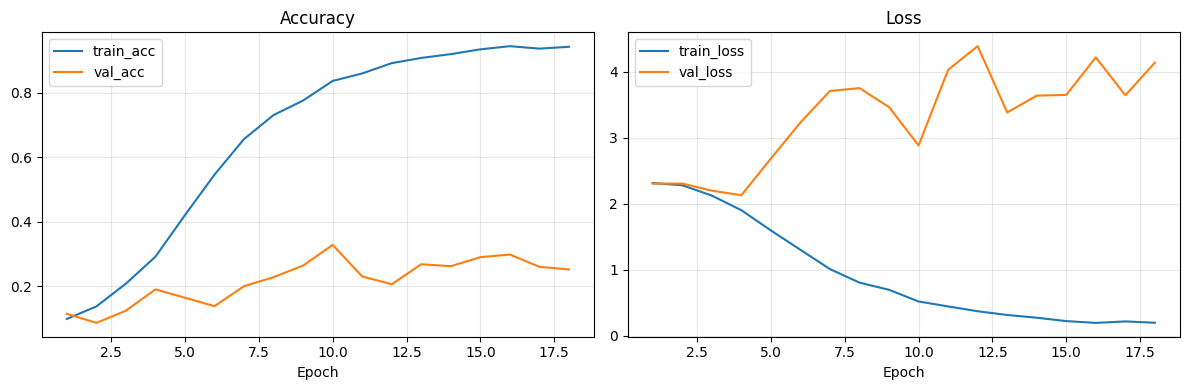

In [ ]:
# @title 3.8 Plot kurva training vs validation accuracy/loss
import matplotlib.pyplot as plt

epochs = [h["epoch"] for h in history]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, [h["train_acc"] for h in history], label="train_acc")
axes[0].plot(epochs, [h["val_acc"] for h in history], label="val_acc")
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [h["train_loss"] for h in history], label="train_loss")
axes[1].plot(epochs, [h["val_loss"] for h in history], label="val_loss")
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Bagian 4 — Evaluasi pada Test Set

Menghitung accuracy, precision, recall, F1 score (per kelas + rata-rata), confusion matrix, dan ROC/AUC (one-vs-rest) — sama seperti Table 3, 4, 5 dan Figure 6/7 pada jurnal.

In [ ]:
# @title 4.1 Load model terbaik (checkpoint) untuk evaluasi
best_ckpt = torch.load(CONFIG["CHECKPOINT_PATH"], map_location=device)
eval_model = MODEL_REGISTRY[best_ckpt["model_name"]](num_classes=len(best_ckpt["classes"])).to(device)
eval_model.load_state_dict(best_ckpt["model_state"])
eval_model.eval()
print(f"Model '{best_ckpt['model_name']}' (Val Acc={best_ckpt['val_acc']:.2%}) siap dievaluasi.")

NameError: name 'MODEL_REGISTRY' is not defined

In [ ]:
# @title 4.2 Precision, Recall, F1-score, dan Accuracy pada test set
from sklearn.metrics import classification_report, accuracy_score

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = eval_model(x)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(pred)
        all_labels.extend(y.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc:.2%}\n")
print(classification_report(all_labels, all_preds, target_names=dataset.classes, digits=3))
# --- Kirim hasil evaluasi per-kelas ke wandb sebagai Table (kalau masih ada run aktif) ---
if CONFIG["USE_WANDB"]:
    import wandb
    from sklearn.metrics import precision_recall_fscore_support
    if wandb.run is not None:
        precisions, recalls, f1s, supports = precision_recall_fscore_support(
            all_labels, all_preds, labels=range(len(dataset.classes))
        )
        table = wandb.Table(columns=["class", "precision", "recall", "f1", "support"])
        for c, p, r, f, s in zip(dataset.classes, precisions, recalls, f1s, supports):
            table.add_data(c, float(p), float(r), float(f), int(s))
        wandb.log({"test_accuracy": test_acc, "per_class_metrics": table})


Test Accuracy: 95.08%

              precision    recall  f1-score   support

        Maaf      1.000     0.973     0.986        37
      Tolong      1.000     0.950     0.974        40
     Permisi      1.000     0.951     0.975        41
        Halo      0.885     0.958     0.920        24
       Mulai      1.000     0.913     0.955        46
    Berhenti      0.844     0.974     0.905        39
      Lanjut      0.974     0.949     0.961        39
       Sakit      0.919     0.895     0.907        38
     Kembali      0.939     1.000     0.969        31
        Awas      0.938     0.968     0.952        31

    accuracy                          0.951       366
   macro avg      0.950     0.953     0.950       366
weighted avg      0.954     0.951     0.951       366



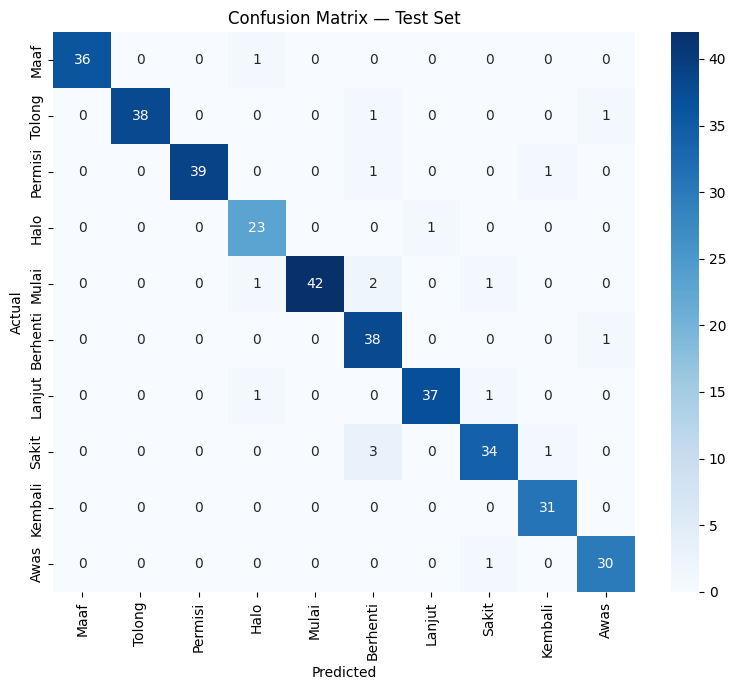

In [ ]:
# @title 4.3 Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()
if CONFIG["USE_WANDB"]:
    import wandb
    if wandb.run is not None:
        plt.savefig("/content/confusion_matrix.png", dpi=120)
        wandb.log({"confusion_matrix_img": wandb.Image("/content/confusion_matrix.png")})


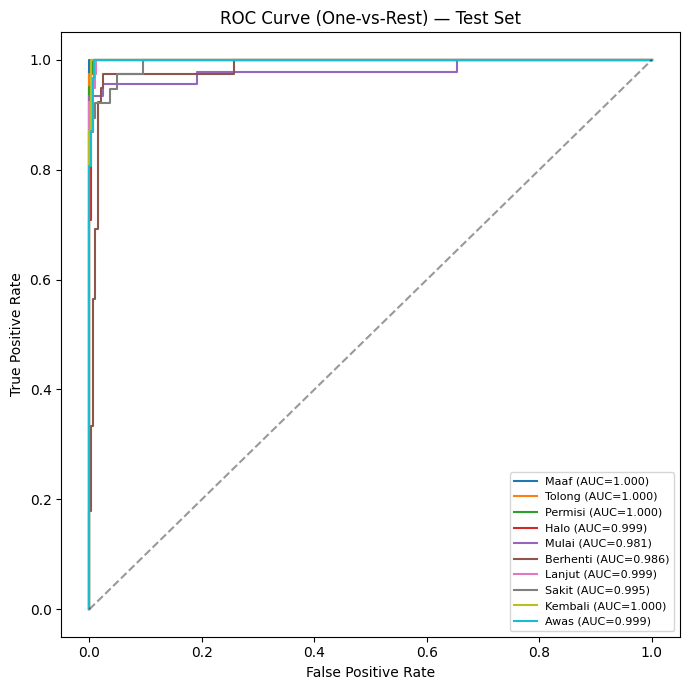

In [ ]:
# @title 4.4 ROC curve & AUC (one-vs-rest), sesuai Figure 6/7 jurnal
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

all_probs = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = eval_model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.extend(probs)
all_probs = np.array(all_probs)

n_classes = len(dataset.classes)
y_bin = label_binarize(all_labels, classes=list(range(n_classes)))

plt.figure(figsize=(7, 7))
for i, cls_name in enumerate(dataset.classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls_name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest) — Test Set")
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()